In [1]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

import scipy.signal as sp_sig

In [2]:
frequency = 10000         # Hz
FS = 240000               # Hz

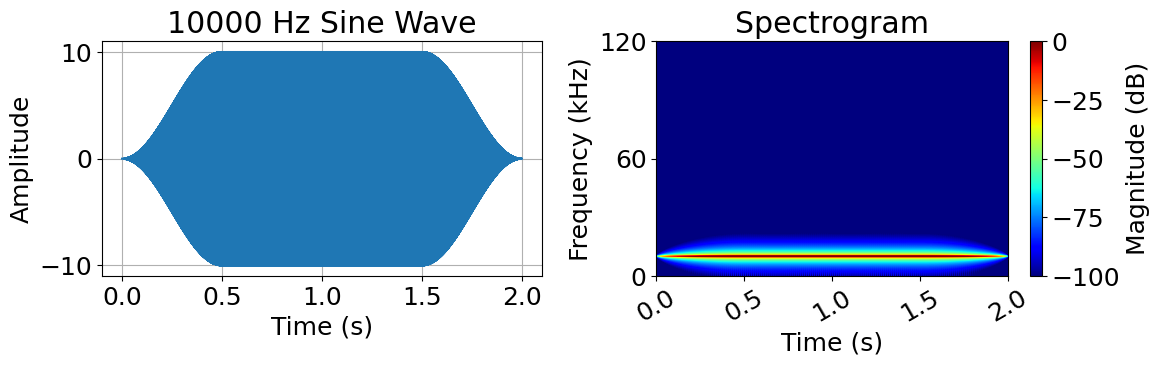

In [11]:
TIME_DURATION = 2        # seconds
t = np.linspace(0, TIME_DURATION, int(FS * TIME_DURATION), endpoint=False)

sine_wave = np.sin(2 * np.pi * frequency * t)
window_func = sp_sig.windows.tukey(int(FS*TIME_DURATION))
amp = 10
save_sig = sine_wave*window_func * amp

fig, ax_all = plt.subplots(1, 2, figsize=(12, 4))
plt.rcParams.update({'font.size': 18})

ax = ax_all[0]
ax.plot(t, save_sig)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"{int(frequency)} Hz Sine Wave")
ax.grid(which='both')

vmax = 0
vmin = -100

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

vmax = spec_features['vmax']
vmin = spec_features['vmin']
cmap = spec_features['cmap']
nfft = spec_features['NFFT']

ax = ax_all[1]
_, _, _, im = ax.specgram(save_sig, NFFT=nfft, Fs=FS, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
ax.set_yticks(ticks=np.linspace(0, FS/2, 3), labels=np.linspace(0, FS/2000, 3).astype('int'))
xticks_sec = np.linspace(0, TIME_DURATION, 5)
xtick_labels_ms = (xticks_sec)

ax.set_xticks(xticks_sec)
ax.set_xticklabels(xtick_labels_ms, rotation=30)
ax.set_ylabel('Frequency (kHz)')
ax.set_xlabel('Time (s)')
ax.set_title(f"Spectrogram")
fig.colorbar(ax=ax, mappable=im, label='Magnitude (dB)')

fig.tight_layout()
plt.show()

/Users/adityakrishna/miniforge3/envs/bat_msds/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8091: RuntimeWarning: divide by zero encountered in log10
  Z = 20. * np.log10(spec)


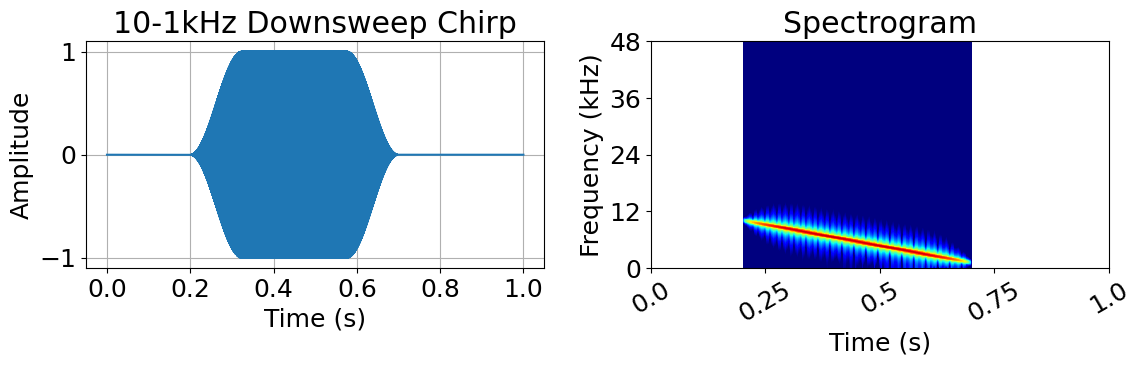

In [47]:
TIME_DURATION = 1
t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
sig_duration = 0.5
raw_signal = sp_sig.chirp(np.linspace(0, sig_duration, int(FS*sig_duration)), f0=10000, t1=sig_duration, f1=1000)
window_func = sp_sig.windows.tukey(int(FS*sig_duration))

signal = np.zeros(t.size)
time_transmitted = 0.2
signal[round(FS*time_transmitted):round(FS*(time_transmitted+sig_duration))] = raw_signal * window_func

fig, ax_all = plt.subplots(1, 2, figsize=(12, 4))
plt.rcParams.update({'font.size': 18})

ax = ax_all[0]
ax.plot(t, signal)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"{int(frequency/1000)}-{int(frequency/10000)}kHz Downsweep Chirp")
ax.grid(which='both')

vmax = 0
vmin = -100

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

vmax = spec_features['vmax']
vmin = spec_features['vmin']
cmap = spec_features['cmap']
nfft = spec_features['NFFT']

ax = ax_all[1]
_, _, _, im = ax.specgram(signal, NFFT=nfft, Fs=FS, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
ax.set_yticks(ticks=np.arange(0, 48e3+1, 12e3), labels=np.arange(0, 48+1, 12))
ax.set_ylim(0, 48e3)
xticks_sec = np.linspace(0, TIME_DURATION, 5)
xtick_labels_ms = (xticks_sec)

ax.set_xticks(xticks_sec)
ax.set_xticklabels(xtick_labels_ms, rotation=30)
ax.set_ylabel('Frequency (kHz)')
ax.set_xlabel('Time (s)')
ax.set_title(f"Spectrogram")

fig.tight_layout()
plt.show()

In [13]:
sf.write(f"test_chirp_bird1s_10kHz_to_1kHz.wav", signal, FS)

In [23]:
len((raw_signal * window_func) / 2)

120000

In [25]:
round(FS*time_transmitted), round(FS*(time_transmitted+sig_duration))

(36000000, 36120000)

In [22]:
round(FS*(time_transmitted+sig_duration))

36120000

/Users/adityakrishna/miniforge3/envs/bat_msds/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8091: RuntimeWarning: divide by zero encountered in log10
  Z = 20. * np.log10(spec)


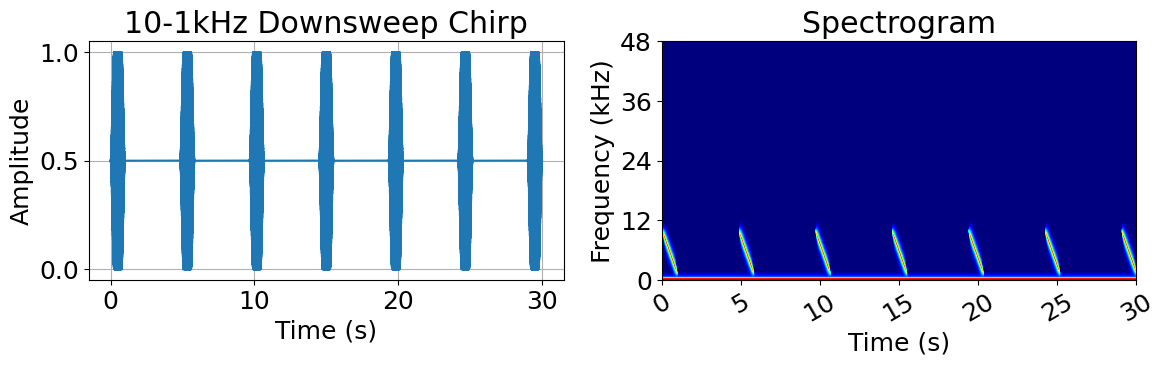

In [56]:
TIME_DURATION = 30
t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
sig_duration = 1
raw_signal = sp_sig.chirp(np.linspace(0, sig_duration, int(FS*sig_duration)), f0=10000, t1=sig_duration, f1=1000)
window_func = sp_sig.windows.tukey(int(FS*sig_duration))

bird_signal = np.zeros(t.size)

num_calls = 0
for time_transmitted in np.linspace(0, (TIME_DURATION - sig_duration), 7):
    num_calls+=1
    bird_signal[round(FS*time_transmitted):round(FS*(time_transmitted+sig_duration))] = (raw_signal * window_func) / 2
save_sig = (bird_signal + 0.5)

fig, ax_all = plt.subplots(1, 2, figsize=(12, 4))
plt.rcParams.update({'font.size': 18})

ax = ax_all[0]
ax.plot(t, save_sig)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"{int(frequency/1000)}-{int(frequency/10000)}kHz Downsweep Chirp")
ax.grid(which='both')

vmax = 0
vmin = -100

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

vmax = spec_features['vmax']
vmin = spec_features['vmin']
cmap = spec_features['cmap']
nfft = spec_features['NFFT']

ax = ax_all[1]
_, _, _, im = ax.specgram(save_sig, NFFT=nfft, Fs=FS, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
ax.set_yticks(ticks=np.arange(0, 48e3+1, 12e3), labels=np.arange(0, 48+1, 12))
ax.set_ylim(0, 48e3)
xticks_sec = np.linspace(0, TIME_DURATION, 7).astype(int)
xtick_labels_ms = (xticks_sec)

ax.set_xticks(xticks_sec)
ax.set_xticklabels(xtick_labels_ms, rotation=30)
ax.set_ylabel('Frequency (kHz)')
ax.set_xlabel('Time (s)')
ax.set_title(f"Spectrogram")

fig.tight_layout()
plt.show()

In [57]:
sf.write(f"test_30s_bird_chirp_sequence_10kHz_to_1kHz.wav", save_sig, FS)

/Users/adityakrishna/miniforge3/envs/bat_msds/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8091: RuntimeWarning: divide by zero encountered in log10
  Z = 20. * np.log10(spec)


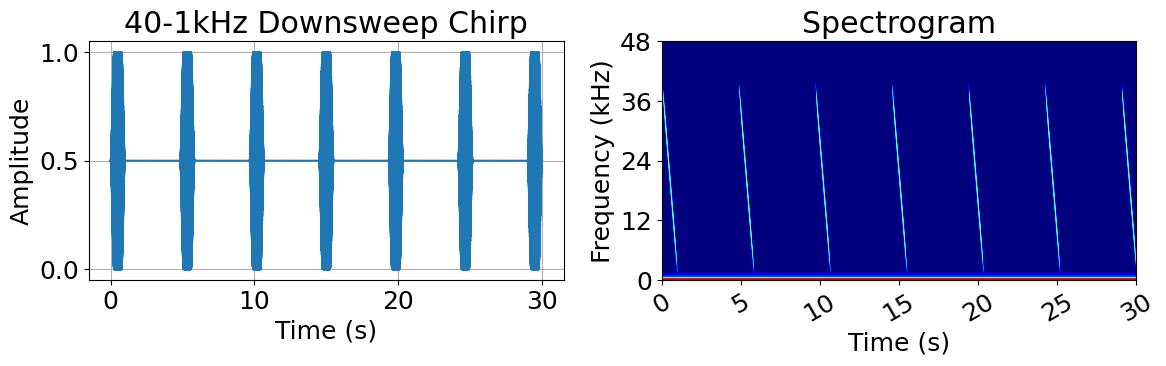

In [58]:
TIME_DURATION = 30
t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
sig_duration = 1
raw_signal = sp_sig.chirp(np.linspace(0, sig_duration, int(FS*sig_duration)), f0=40000, t1=sig_duration, f1=1000)
window_func = sp_sig.windows.tukey(int(FS*sig_duration))

signal = np.zeros(t.size)

num_calls = 0
for time_transmitted in np.linspace(0, (TIME_DURATION - sig_duration), 7):
    num_calls+=1
    signal[round(FS*time_transmitted):round(FS*(time_transmitted+sig_duration))] = (raw_signal * window_func) / 2
save_sig = (signal + 0.5)

fig, ax_all = plt.subplots(1, 2, figsize=(12, 4))
plt.rcParams.update({'font.size': 18})

ax = ax_all[0]
ax.plot(t, save_sig)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"40-{int(frequency/10000)}kHz Downsweep Chirp")
ax.grid(which='both')

vmax = 0
vmin = -100

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

vmax = spec_features['vmax']
vmin = spec_features['vmin']
cmap = spec_features['cmap']
nfft = spec_features['NFFT']

ax = ax_all[1]
_, _, _, im = ax.specgram(save_sig, NFFT=nfft, Fs=FS, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
ax.set_yticks(ticks=np.arange(0, 48e3+1, 12e3), labels=np.arange(0, 48+1, 12))
ax.set_ylim(0, 48e3)
xticks_sec = np.linspace(0, TIME_DURATION, 7).astype(int)
xtick_labels_ms = (xticks_sec)

ax.set_xticks(xticks_sec)
ax.set_xticklabels(xtick_labels_ms, rotation=30)
ax.set_ylabel('Frequency (kHz)')
ax.set_xlabel('Time (s)')
ax.set_title(f"Spectrogram")

fig.tight_layout()
plt.show()

In [59]:
sf.write(f"test_30s_bat_chirp_sequence_40kHz_to_1kHz.wav", save_sig, FS)

/Users/adityakrishna/miniforge3/envs/bat_msds/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8091: RuntimeWarning: divide by zero encountered in log10
  Z = 20. * np.log10(spec)


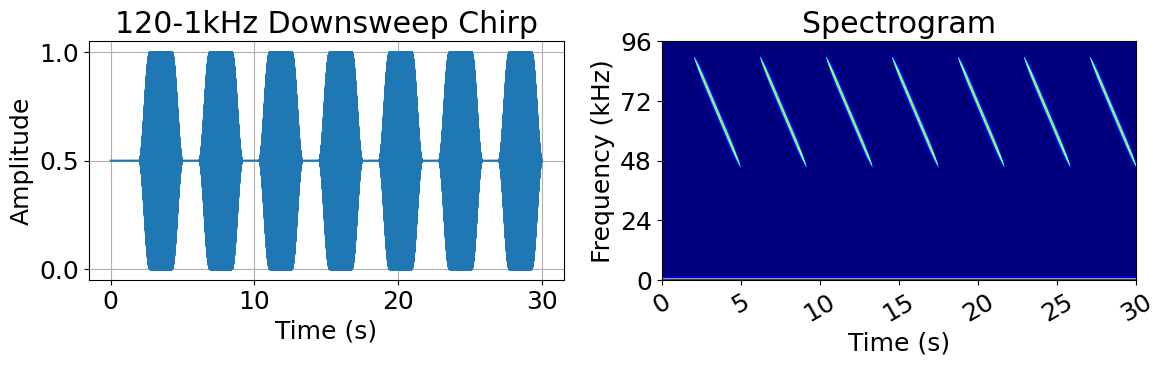

In [62]:
TIME_DURATION = 30
t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
sig_duration = 3
raw_signal = sp_sig.chirp(np.linspace(0, sig_duration, int(FS*sig_duration)), f0=90000, t1=sig_duration, f1=45000)
window_func = sp_sig.windows.tukey(int(FS*sig_duration))

bat_signal = np.zeros(t.size)

num_calls = 0
for time_transmitted in np.linspace(2, (TIME_DURATION - sig_duration), 7):
    num_calls+=1
    bat_signal[round(FS*time_transmitted):round(FS*(time_transmitted+sig_duration))] = (raw_signal * window_func) / 2
save_sig = (bat_signal + 0.5)

fig, ax_all = plt.subplots(1, 2, figsize=(12, 4))
plt.rcParams.update({'font.size': 18})

ax = ax_all[0]
ax.plot(t, save_sig)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"120-{int(frequency/10000)}kHz Downsweep Chirp")
ax.grid(which='both')

vmax = 0
vmin = -100

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

vmax = spec_features['vmax']
vmin = spec_features['vmin']
cmap = spec_features['cmap']
nfft = spec_features['NFFT']

ax = ax_all[1]
_, _, _, im = ax.specgram(save_sig, NFFT=nfft, Fs=FS, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
ax.set_yticks(ticks=np.arange(0, 96e3+1, 24e3), labels=np.arange(0, 96+1, 24))
ax.set_ylim(0, 96e3)
xticks_sec = np.linspace(0, TIME_DURATION, 7).astype(int)
xtick_labels_ms = (xticks_sec)

ax.set_xticks(xticks_sec)
ax.set_xticklabels(xtick_labels_ms, rotation=30)
ax.set_ylabel('Frequency (kHz)')
ax.set_xlabel('Time (s)')
ax.set_title(f"Spectrogram")

fig.tight_layout()
plt.show()

/Users/adityakrishna/miniforge3/envs/bat_msds/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8091: RuntimeWarning: divide by zero encountered in log10
  Z = 20. * np.log10(spec)


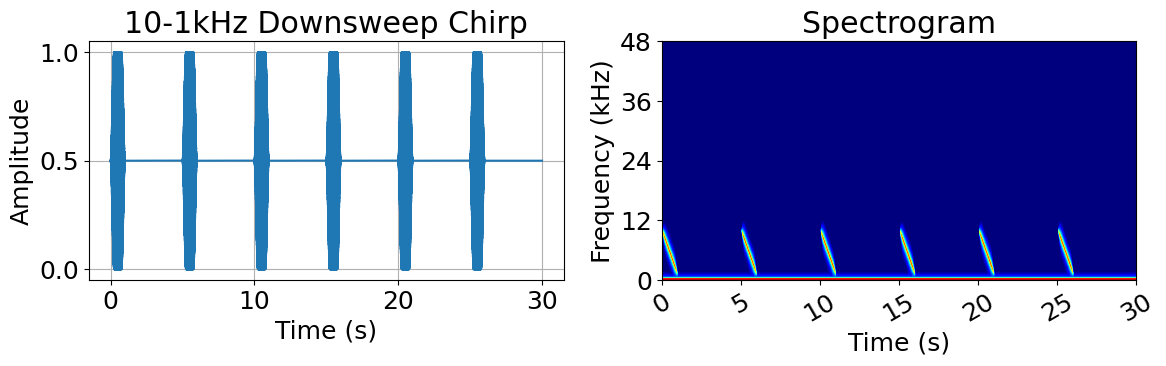

In [76]:
TIME_DURATION = 30
t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
sig_duration = 1
raw_signal = sp_sig.chirp(np.linspace(0, sig_duration, int(FS*sig_duration)), f0=10000, t1=sig_duration, f1=1000)
window_func = sp_sig.windows.tukey(int(FS*sig_duration))

bird_signal = np.zeros(t.size)

num_calls = 0
for time_transmitted in np.arange(0, (TIME_DURATION - sig_duration), 5):
    num_calls+=1
    bird_signal[round(FS*time_transmitted):round(FS*(time_transmitted+sig_duration))] = (raw_signal * window_func) / 2
save_sig = (bird_signal + 0.5)

fig, ax_all = plt.subplots(1, 2, figsize=(12, 4))
plt.rcParams.update({'font.size': 18})

ax = ax_all[0]
ax.plot(t, save_sig)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"{int(frequency/1000)}-{int(frequency/10000)}kHz Downsweep Chirp")
ax.grid(which='both')

vmax = 0
vmin = -100

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

vmax = spec_features['vmax']
vmin = spec_features['vmin']
cmap = spec_features['cmap']
nfft = spec_features['NFFT']

ax = ax_all[1]
_, _, _, im = ax.specgram(save_sig, NFFT=nfft, Fs=FS, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
ax.set_yticks(ticks=np.arange(0, 48e3+1, 12e3), labels=np.arange(0, 48+1, 12))
ax.set_ylim(0, 48e3)
xticks_sec = np.linspace(0, TIME_DURATION, 7).astype(int)
xtick_labels_ms = (xticks_sec)

ax.set_xticks(xticks_sec)
ax.set_xticklabels(xtick_labels_ms, rotation=30)
ax.set_ylabel('Frequency (kHz)')
ax.set_xlabel('Time (s)')
ax.set_title(f"Spectrogram")

fig.tight_layout()
plt.show()

/Users/adityakrishna/miniforge3/envs/bat_msds/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8091: RuntimeWarning: divide by zero encountered in log10
  Z = 20. * np.log10(spec)


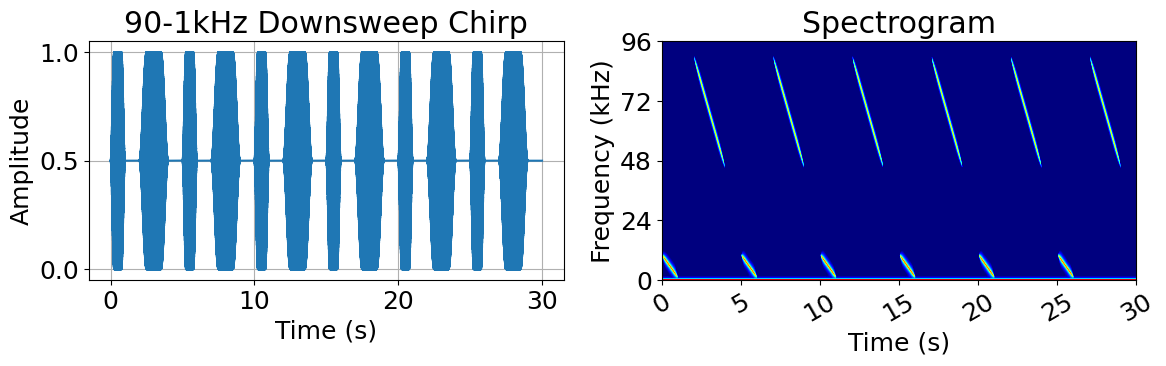

In [80]:
TIME_DURATION = 30
t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
sig_duration = 2
raw_signal = sp_sig.chirp(np.linspace(0, sig_duration, int(FS*sig_duration)), f0=90000, t1=sig_duration, f1=45000)
window_func = sp_sig.windows.tukey(int(FS*sig_duration))

bat_signal = np.zeros(t.size)

num_calls = 0
for time_transmitted in np.arange(2, (TIME_DURATION - sig_duration), 5):
    num_calls+=1
    bat_signal[round(FS*time_transmitted):round(FS*(time_transmitted+sig_duration))] = (raw_signal * window_func) / 2
save_sig = (bat_signal + bird_signal + 0.5)

fig, ax_all = plt.subplots(1, 2, figsize=(12, 4))
plt.rcParams.update({'font.size': 18})

ax = ax_all[0]
ax.plot(t, save_sig)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"90-{int(frequency/10000)}kHz Downsweep Chirp")
ax.grid(which='both')

vmax = 0
vmin = -100

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

vmax = spec_features['vmax']
vmin = spec_features['vmin']
cmap = spec_features['cmap']
nfft = spec_features['NFFT']

ax = ax_all[1]
_, _, _, im = ax.specgram(save_sig, NFFT=nfft, Fs=FS, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
ax.set_yticks(ticks=np.arange(0, 96e3+1, 24e3), labels=np.arange(0, 96+1, 24))
ax.set_ylim(0, 96e3)
xticks_sec = np.linspace(0, TIME_DURATION, 7).astype(int)
xtick_labels_ms = (xticks_sec)

ax.set_xticks(xticks_sec)
ax.set_xticklabels(xtick_labels_ms, rotation=30)
ax.set_ylabel('Frequency (kHz)')
ax.set_xlabel('Time (s)')
ax.set_title(f"Spectrogram")

fig.tight_layout()
plt.show()

In [79]:
sf.write(f"test_30s_bat_and_bird_chirp_sequence_90kHz_to_1kHz.wav", save_sig, FS)

In [47]:
speaker_R = 4
speaker_W = 10

speaker_V_rms = (speaker_R*speaker_W)**0.5
speaker_V_rms

6.324555320336759

In [48]:
speaker_M = 92 # db SPL / 2.83 vrms / 1m at 50kHz
ref_M_vrms = 2.83

In [56]:
VIFA_SPL = speaker_M + 20*np.log10(speaker_V_rms / ref_M_vrms)

In [57]:
VIFA_SPL

98.98487120279381

In [51]:
speaker_max_output_level_ref_36VDC = 98 #dB SPL

In [52]:
def attenuation_downwind_linear_regression(distance_in_meters):
    return (distance_in_meters + 84.72) / 3.77

def attenuation_nowind_linear_regression(distance_in_meters):
    return (distance_in_meters + 66.69) / 3.39

def attenuation_upwind_linear_regression(distance_in_meters):
    return (distance_in_meters + 33.13) / 2.28

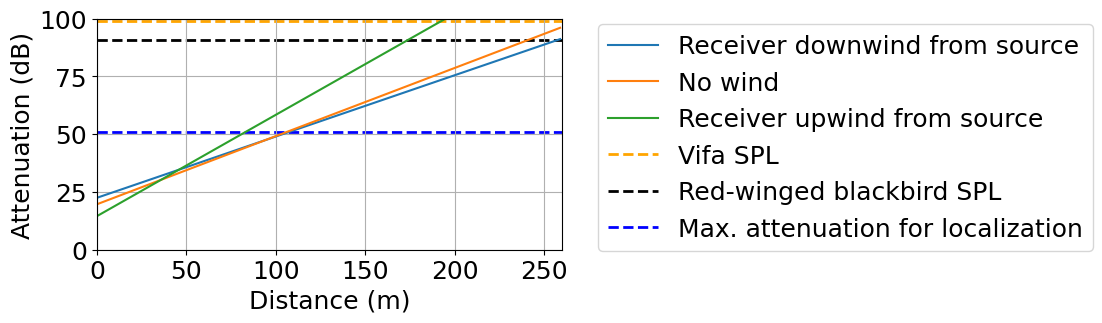

In [59]:
begin_dist = 0
end_dist = 260
distances_from_recorder = np.arange(begin_dist, end_dist)
attenuation_for_upwind = attenuation_upwind_linear_regression(distances_from_recorder)
attenuation_for_nowind = attenuation_nowind_linear_regression(distances_from_recorder)
attenuation_for_downwind = attenuation_downwind_linear_regression(distances_from_recorder)

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(attenuation_for_downwind, label='Receiver downwind from source', zorder=2)
ax.plot(attenuation_for_nowind, label='No wind', zorder=2)
ax.plot(attenuation_for_upwind, label='Receiver upwind from source', zorder=2)

ax.axhline(y=VIFA_SPL, linestyle='dashed', color='orange', linewidth=2, zorder=1, label='Vifa SPL')

REDWINGED_BLACKBIRD_SPL = 90.8 #dB SPL
ax.axhline(y=REDWINGED_BLACKBIRD_SPL, linestyle='dashed', color='k', linewidth=2, zorder=1, label='Red-winged blackbird SPL')

LOCALIZATION_THRESHOLD = 40
ax.axhline(y=REDWINGED_BLACKBIRD_SPL - LOCALIZATION_THRESHOLD, linestyle='dashed', color='blue', linewidth=2, zorder=1, label='Max. attenuation for localization')

ax.set_ylabel("Attenuation (dB)")
ax.set_xlabel('Distance (m)')
ax.grid(which='both')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1.03))
ax.set_xlim(begin_dist, end_dist)
ax.set_ylim(0, 100)

plt.show()